# ECG Baseline Model
An ECG-only 1D CNN for HFrEF prediction. The processed data is split at the subject level to prevent data leakage and handle class imbalance using a weighted loss function.

In [21]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import librosa

from torch.utils.data import Dataset, DataLoader

sys.path.append(os.path.abspath('..'))
from src.data_loader import get_dataloaders
from src.preprocessing import preprocess_signals, segment_signals
from src.ecg_model import ECG_Encoder

metadata = pd.read_csv('../data/processed/processed_metadata.csv')

# split data ensuring segments from the same Record_ID stay together to prevent leakage
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, val_idx = next(gss.split(metadata, groups=metadata['Record_ID']))

train_df = metadata.iloc[train_idx]
val_df = metadata.iloc[val_idx]

print(f"Training segments: {len(train_df)}")
print(f"Validation segments: {len(val_df)}")

Training segments: 9600
Validation segments: 2400


## Initialize Dataloaders and Model
PyTorch `.pt` tensors are directly loaded from the disk.

In [2]:
PROCESSED_DIR = '../data/processed/'

# initialize custom dataloaders
train_loader, val_loader = get_dataloaders(train_df, val_df, data_dir=PROCESSED_DIR, batch_size=16)

# setup device for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# initialize model
ecg_model = ECG_Encoder().to(device)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")
print(f"Model initialized on device: {device}")

DataLoaders ready. Training batches: 600
Model initialized on device: cuda


## Training Loop
Binary Cross Entropy with Logits Loss (`BCEWithLogitsLoss`) is used. Since we have few HFrEF subjects (1760 Normal to 240 HFrEF), a positive weight of ~7.3 is applied to the loss function to penalize the model heavily if it misses an HFrEF case.

In [3]:
os.makedirs('../models', exist_ok=True) # create models directory if it doesn't exist

# Manually set hyperparameters
num_epochs = 10
learning_rate = 1e-3

pos_weight = torch.tensor([7.3]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(ecg_model.parameters(), lr=learning_rate)

best_auroc = 0.0
MODEL_SAVE_PATH = '../models/best_ecg_model.pt'

for epoch in range(num_epochs):
    # training
    ecg_model.train()
    train_loss = 0.0
    
    for ecg, pcg, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        ecg = ecg.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = ecg_model(ecg)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * ecg.size(0)
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
    
    # validation
    ecg_model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for ecg, pcg, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            ecg = ecg.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            outputs = ecg_model(ecg)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * ecg.size(0)
            
            # sigmoid to convert raw logits to probabilities
            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    # calculate metrics
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)
    
    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")
    
    # save model if AUROC improves
    if auroc > best_auroc:
        print(f"Validation AUROC improved from {best_auroc:.4f} to {auroc:.4f}. Saving improved model.")
        best_auroc = auroc
        torch.save(ecg_model.state_dict(), MODEL_SAVE_PATH) # save state_dict() instead of the whole model

Epoch 1/10 [Val]: 100%|██████████| 150/150 [00:08<00:00, 17.96it/s]


Epoch 1 | Train Loss: 1.1859 | Val Loss: 1.2757 | AUROC: 0.6457 | AUPRC: 0.2380
Validation AUROC improved from 0.0000 to 0.6457. Saving improved model.


Epoch 2/10 [Val]: 100%|██████████| 150/150 [00:04<00:00, 32.03it/s]


Epoch 2 | Train Loss: 1.1472 | Val Loss: 1.3746 | AUROC: 0.6581 | AUPRC: 0.2624
Validation AUROC improved from 0.6457 to 0.6581. Saving improved model.


Epoch 3/10 [Val]: 100%|██████████| 150/150 [00:05<00:00, 25.13it/s]


...

Epoch 8 | Train Loss: 1.0649 | Val Loss: 1.2095 | AUROC: 0.6715 | AUPRC: 0.2519


Epoch 9/10 [Val]: 100%|██████████| 150/150 [00:07<00:00, 19.12it/s]


Epoch 9 | Train Loss: 1.0487 | Val Loss: 1.1958 | AUROC: 0.6736 | AUPRC: 0.2593


Epoch 10/10 [Val]: 100%|██████████| 150/150 [00:03<00:00, 43.08it/s]

Epoch 10 | Train Loss: 1.0338 | Val Loss: 1.1874 | AUROC: 0.6858 | AUPRC: 0.2566
Validation AUROC improved from 0.6805 to 0.6858. Saving improved model.


## Model Evaluation

Optimal Probability Cutoff: 0.5452
Max F1-Score: 0.3279
Confusion Matrix:
[[1319  751]
 [ 118  212]]


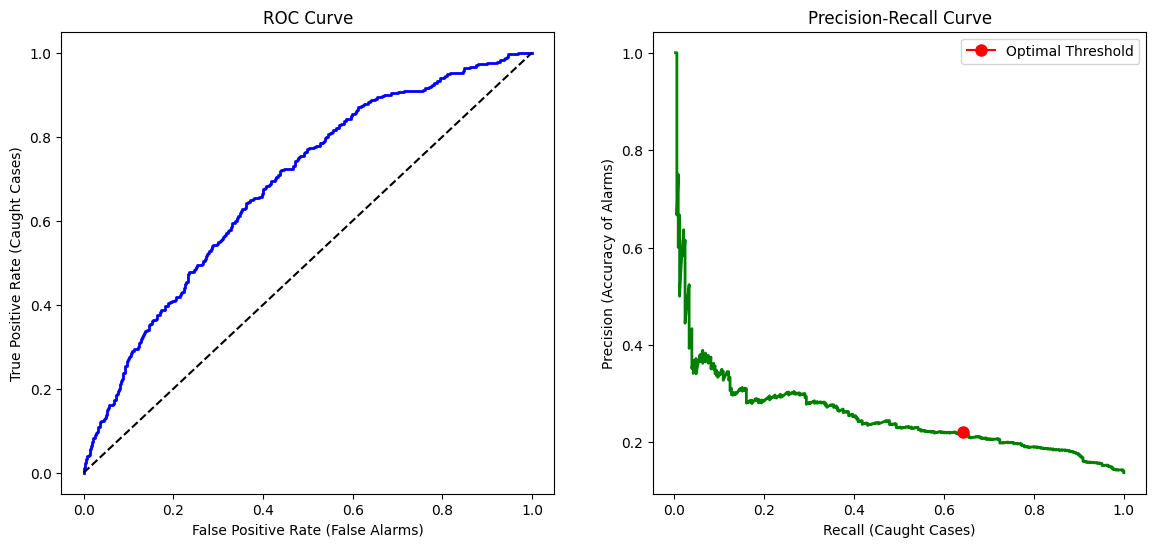

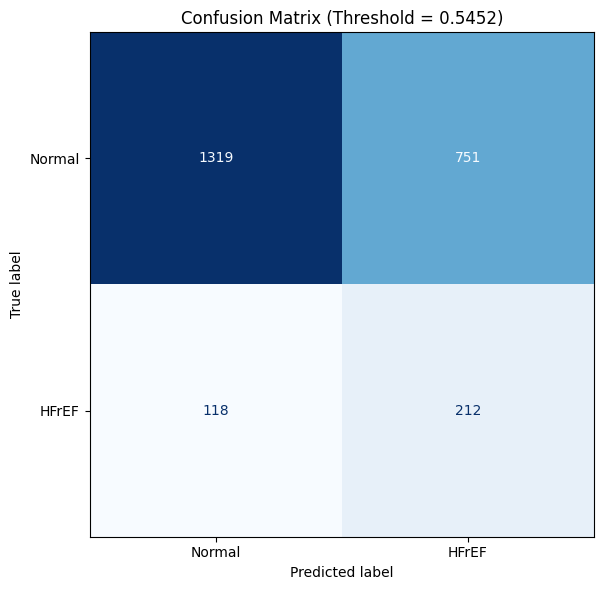

In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

# load the best saved weights
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
ecg_model.eval()

# gather predictions on validation set
all_labels = []
all_preds = []
with torch.no_grad():
    for ecg, _, labels in val_loader:
        ecg = ecg.to(device)
        preds = torch.sigmoid(ecg_model(ecg))
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# calculate optimal threshold (F1-Score)
precisions, recalls, thresholds_pr = precision_recall_curve(all_labels, all_preds)

# calculate F1 for all thresholds (adding 1e-8 to avoid division by zero)
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_idx]

print(f"Optimal Probability Cutoff: {optimal_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[optimal_idx]:.4f}")

# confusion matrix
binary_preds = (np.array(all_preds) >= optimal_threshold).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
# print("\nClassification Report:")
# print(classification_report(all_labels, binary_preds))

# ROC Curve data
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_preds)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve (AUROC)
axes[0].plot(fpr, tpr, color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0].set_xlabel('False Positive Rate (False Alarms)')
axes[0].set_ylabel('True Positive Rate (Caught Cases)')
axes[0].set_title('ROC Curve')

# Precision-Recall Curve (AUPRC)
axes[1].plot(recalls[:-1], precisions[:-1], color='green', lw=2)
# Mark the optimal threshold on the PR curve
axes[1].plot(recalls[optimal_idx], precisions[optimal_idx], marker='o', markersize=8, color="red", label="Optimal Threshold")
axes[1].set_xlabel('Recall (Caught Cases)')
axes[1].set_ylabel('Precision (Accuracy of Alarms)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

print('Confusion Matrix:')
print(cm)

# Confusion Matrix (separate figure for readability)
fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

### Observations on the results

- The model learns meaningful signal: the validation **AUROC reaches 0.6858**, which is better than random (0.50) but still indicates only moderate class separation. The best **AUPRC is 0.2836**, so performance remains challenging for the minority HFrEF class.
- The cutoff **0.5452** is not a medical threshold. It was selected by testing the validation predictions at different probability thresholds and choosing the one with the highest **F1-score (0.3279)**, balancing precision and recall.
- At this cutoff, HFrEF recall is about **64%**, meaning the model catches around 64% of HFrEF segments. HFrEF precision is only **22%**, meaning many positive predictions are false alarms. Because the validation set is imbalanced (330 HFrEF vs 2070 Normal), accuracy alone is not very informative.
- The **ROC curve** shows the trade-off between sensitivity (TPR) and false-positive rate across thresholds. The **Precision-Recall curve** is especially useful here because HFrEF is the minority class: it shows how much precision must be sacrificed to obtain higher recall.

### Better workflow / What to improve next

- Keep the subject/record-level split to prevent leakage, but introduce a separate **test set**. Use the training set to fit the model, validation set to select the model and decision threshold, and test set only once for final evaluation.
- Choose the threshold based on the intended application rather than automatically optimizing F1. For screening, for example, a higher recall may be more important than precision.
- Evaluate performance at the **patient/record level** when multiple segments come from the same record, rather than treating every segment as an independent clinical prediction.
- For the next iterations, focus on improving minority-class discrimination and inspect the PR curve together with recall, precision, F1, AUROC, and AUPRC rather than relying on accuracy alone.


## Using The Test Set
- It should follow the same preprocessing and segmentation steps as the training/validation data.

In [18]:
TEST_DIR = '../data/raw/HFrEF_community_scenario_test_set/test_set/'
TEST_LABEL_PATH = '../data/raw/HFrEF_community_scenario_test_set/test_set_label.csv'

test_labels_df = pd.read_csv(TEST_LABEL_PATH, header=None, names=['Subject_ID', 'LVEF'])

print("Test label columns:")
print(test_labels_df.columns.tolist())

print("\nFirst rows:")
print(test_labels_df.head())

print("\nShape:")
print(test_labels_df.shape)

test_labels_df['Label'] = (test_labels_df['LVEF'] <= 0.4).astype(int)

# Make Subject_ID consistently string-based
test_labels_df['Subject_ID'] = test_labels_df['Subject_ID'].astype(str)

print("Test subjects:")
print(test_labels_df['Label'].value_counts().sort_index())

Test label columns:
['Subject_ID', 'LVEF']

First rows:
   Subject_ID  LVEF
0  2024041523  0.57
1  2024041522  0.62
2  2024041521  0.61
3  2024041520  0.60
4  2024041519  0.42

Shape:
(120, 2)
Test subjects:
Label
0    115
1      5
Name: count, dtype: int64


In [19]:
test_records = []

for filename in os.listdir(TEST_DIR):
    if not filename.endswith('_ECG.wav'):
        continue

    # Example:
    # 1011486422_APEX_ECG.wav
    #        ↓
    # 1011486422_APEX
    record_id = filename[:-len('_ECG.wav')]

    # Example:
    # 1011486422_APEX
    #        ↓
    # 1011486422
    subject_id = record_id.split('_')[0]

    ecg_path = os.path.join(TEST_DIR, f'{record_id}_ECG.wav')

    pcg_path = os.path.join(TEST_DIR, f'{record_id}_PCG.wav')

    if not os.path.exists(pcg_path):
        print(f"Warning: missing PCG for {record_id}")
        continue

    # Find subject label
    matches = test_labels_df[test_labels_df['Subject_ID'] == subject_id]

    if len(matches) == 0:
        print(f"Warning: no label found for {subject_id}")
        continue

    if len(matches) > 1:
        print(f"Warning: multiple labels found for {subject_id}")

    label = int(matches.iloc[0]['Label'])

    test_records.append({
        'Subject_ID': subject_id,
        'Record_ID': record_id,
        'ECG_Path': ecg_path,
        'PCG_Path': pcg_path,
        'Label': label
    })

test_records_df = pd.DataFrame(test_records)

print(f"\nTest recordings found: {len(test_records_df)}")
print(test_records_df.head())


Test recordings found: 480
   Subject_ID        Record_ID  \
0  1011486422  1011486422_APEX   
1  1011486422  1011486422_LLSB   
2  1011486422  1011486422_LUSB   
3  1011486422  1011486422_RUSB   
4  2024031801  2024031801_APEX   

                                            ECG_Path  \
0  ../data/raw/HFrEF_community_scenario_test_set/...   
1  ../data/raw/HFrEF_community_scenario_test_set/...   
2  ../data/raw/HFrEF_community_scenario_test_set/...   
3  ../data/raw/HFrEF_community_scenario_test_set/...   
4  ../data/raw/HFrEF_community_scenario_test_set/...   

                                            PCG_Path  Label  
0  ../data/raw/HFrEF_community_scenario_test_set/...      1  
1  ../data/raw/HFrEF_community_scenario_test_set/...      1  
2  ../data/raw/HFrEF_community_scenario_test_set/...      1  
3  ../data/raw/HFrEF_community_scenario_test_set/...      1  
4  ../data/raw/HFrEF_community_scenario_test_set/...      0  


### Preprocessing and Segmentation

In [22]:
test_samples = []

for _, row in test_records_df.iterrows():

    print(f"Processing {row['Record_ID']}...")

    ecg_sig, _ = librosa.load(row['ECG_Path'], sr=500)

    pcg_sig, _ = librosa.load(row['PCG_Path'], sr=4000)

    ecg_clean, pcg_clean = preprocess_signals(ecg_sig, pcg_sig)

    ecg_segs, pcg_segs = segment_signals(ecg_clean, pcg_clean, segment_length_sec=5)

    for seg_idx, ecg_seg in enumerate(ecg_segs):
        test_samples.append({
            'Subject_ID': row['Subject_ID'],
            'Record_ID': row['Record_ID'],
            'Segment_Index': seg_idx,
            'ECG': torch.tensor(
                ecg_seg,
                dtype=torch.float32
            ),
            'Label': row['Label']
        })

print(f"\nTotal test segments: {len(test_samples)}")

Processing 1011486422_APEX...


C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing 1011486422_LLSB...
Processing 1011486422_LUSB...
Processing 1011486422_RUSB...
Processing 2024031801_APEX...
Processing 2024031801_LLSB...
Processing 2024031801_LUSB...
Processing 2024031801_RUSB...
Processing 2024031802_APEX...
Processing 2024031802_LLSB...
Processing 2024031802_LUSB...
Processing 2024031802_RUSB...
Processing 2024031803_APEX...
Processing 2024031803_LLSB...
Processing 2024031803_LUSB...
Processing 2024031803_RUSB...
Processing 2024031804_APEX...
Processing 2024031804_LLSB...
Processing 2024031804_LUSB...
Processing 2024031804_RUSB...
Processing 2024031805_APEX...
Processing 2024031805_LLSB...
Processing 2024031805_LUSB...
Processing 2024031805_RUSB...
Processing 2024031806_APEX...
Processing 2024031806_LLSB...
Processing 2024031806_LUSB...
Processing 2024031806_RUSB...
Processing 2024031807_APEX...
Processing 2024031807_LLSB...
Processing 2024031807_LUSB...
Processing 2024031807_RUSB...
Processing 2024031809_APEX...
Processing 2024031809_LLSB...
Processing

### Create Dataset

In [23]:
class TestECGDataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        # (2500,) -> (1, 2500)
        ecg = sample['ECG'].unsqueeze(0)

        label = torch.tensor(
            sample['Label'],
            dtype=torch.float32
        )

        return ecg, label
    
test_dataset = TestECGDataset(test_samples)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test samples: 2880
Test batches: 180


## Evaluate on Test Set

In [ ]:
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))

ecg_model.eval()

test_labels = []
test_preds = []

with torch.no_grad():

    for ecg, labels in test_loader:

        ecg = ecg.to(device)

        outputs = ecg_model(ecg)
        preds = torch.sigmoid(outputs)

        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

print(f"Optimal threshold: {optimal_threshold}")

Optimal threshold: 0.5451889634132385


## Test Results

Frozen threshold: 0.5452
Test AUROC:       0.7921
Test AUPRC:       0.1753

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9852    0.6529    0.7854      2760
       HFrEF     0.0885    0.7750    0.1588       120

    accuracy                         0.6580      2880
   macro avg     0.5369    0.7139    0.4721      2880
weighted avg     0.9479    0.6580    0.7593      2880


Confusion Matrix:


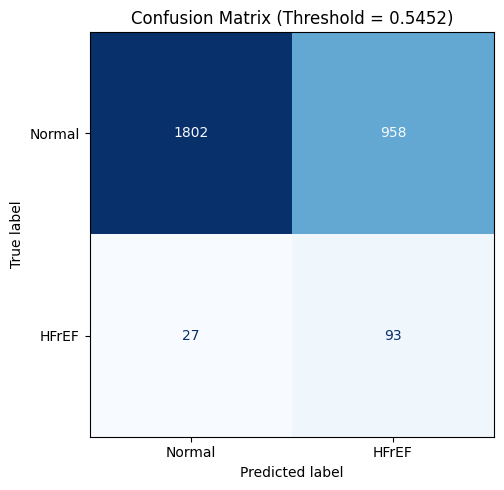

In [ ]:
test_auroc = roc_auc_score(test_labels, test_preds)
test_auprc = average_precision_score(test_labels, test_preds)
test_binary_preds = (test_preds >= optimal_threshold).astype(int)
test_cm = confusion_matrix(test_labels, test_binary_preds)

print(f"Frozen threshold: {optimal_threshold:.4f}")
print(f"Test AUROC:       {test_auroc:.4f}")
print(f"Test AUPRC:       {test_auprc:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds, target_names=['Normal', 'HFrEF'], digits=4))

fig, ax_cm = plt.subplots(figsize=(6, 5))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Normal', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')

plt.tight_layout()
plt.show()